<a href="https://colab.research.google.com/github/jatin-reddy/Semantic_Similarity_NLP/blob/main/Semantic_Similarity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("quora/question-pairs-dataset")

print("Path to dataset files:", path)

100%|██████████| 20.8M/20.8M [00:00<00:00, 261MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/quora/question-pairs-dataset/versions/2


In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


df_path = "/root/.cache/kagglehub/datasets/quora/question-pairs-dataset/versions/2"
df_path = os.path.join(df_path, "questions.csv")
df = pd.read_csv(df_path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404351 entries, 0 to 404350
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404351 non-null  int64 
 1   qid1          404351 non-null  int64 
 2   qid2          404351 non-null  int64 
 3   question1     404350 non-null  object
 4   question2     404349 non-null  object
 5   is_duplicate  404351 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


In [5]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [6]:
print(df.isnull().sum())
df = df.dropna()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64


In [7]:
print(df.isnull().sum())

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64


In [8]:
print(df['is_duplicate'].value_counts())
print(df['is_duplicate'].value_counts(normalize=True))

is_duplicate
0    255042
1    149306
Name: count, dtype: int64
is_duplicate
0    0.630749
1    0.369251
Name: proportion, dtype: float64


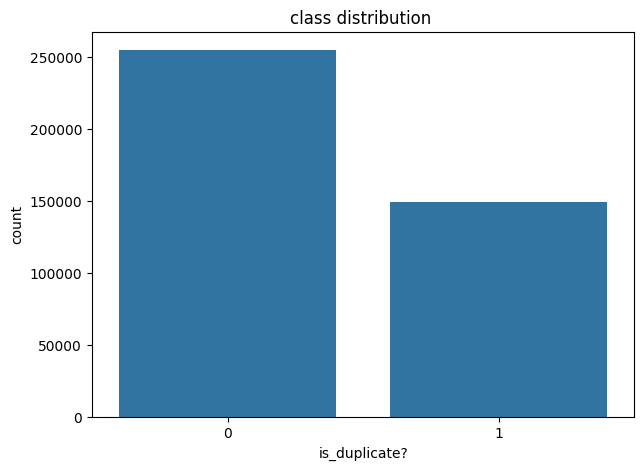

In [9]:
# 0 = not similar, 1 = similar
plt.figure(figsize=(7, 5))
sns.countplot(x='is_duplicate', data=df)
plt.title('class distribution ')
plt.xlabel('is_duplicate?')
plt.ylabel('count')
plt.show()

In [10]:
# We'll use a small random sample to work with
sample_size = 20000
df_sample = df.sample(n=sample_size, random_state=42)
df_sample.head()

,id,qid1,qid2,question1,question2,is_duplicate
371032,371032,726051,726052,Do people realize that you can send marijuana ...,How do you send weed through the mail?,0
263498,263498,518455,518456,How can rock music be brought back?,What would it take for rock music to make a co...,1
111008,111008,220125,220126,Why does one feel relaxed after smoking a join...,How do I sober up quickly after smoking weed/m...,0
75665,75665,150351,150352,How to gain weight ?,How do I gain weight fast but still be healthy?,1
52376,52376,104229,104230,Is porn bad for men?,Can I become a porn fan without getting addicted?,0


In [11]:
!pip install -U sentence-transformers

In [12]:
# Embeddings using Sentence-BERT (bi-encoders: sentence-transformers/all-MiniLM-L6-v2)
# https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2

from sentence_transformers import SentenceTransformer
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

unique_questions_set = set(df_sample['question1']) | set(df_sample['question2'])
unique_questions_list = list(unique_questions_set)


print(f"sample question pairs = {len(df_sample)}") #20000
print(f"sample unique questions = {len(unique_questions_list)}")

unique_questions_embeddings = model.encode(unique_questions_list)
print(f"unique questions embeddings shape = {unique_questions_embeddings.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

sample question pairs = 20000
sample unique questions = 37770
unique questions embeddings shape = (37770, 384)


In [13]:
embedding_map = {question: embedding for question, embedding in zip(unique_questions_list, unique_questions_embeddings)}


df_sample['embedding1'] = df_sample['question1'].map(embedding_map)
df_sample['embedding2'] = df_sample['question2'].map(embedding_map)

In [14]:
print(df_sample.head())

            id    qid1    qid2  \
371032  371032  726051  726052   
263498  263498  518455  518456   
111008  111008  220125  220126   
75665    75665  150351  150352   
52376    52376  104229  104230   

                                                question1  \
371032  Do people realize that you can send marijuana ...   
263498                How can rock music be brought back?   
111008  Why does one feel relaxed after smoking a join...   
75665                                How to gain weight ?   
52376                                Is porn bad for men?   

                                                question2  is_duplicate  \
371032             How do you send weed through the mail?             0   
263498  What would it take for rock music to make a co...             1   
111008  How do I sober up quickly after smoking weed/m...             0   
75665     How do I gain weight fast but still be healthy?             1   
52376   Can I become a porn fan without getting addic

In [15]:
# Cosine Similarity (cos theta = a.b/||a||b||) - needs 2D arrays, but embeddings are list (384,)
from sklearn.metrics.pairwise import cosine_similarity

def calculate_similarity(row):
    a = row['embedding1'].reshape(1, -1)
    b = row['embedding2'].reshape(1, -1)
    return cosine_similarity(a, b)[0][0]

df_sample['similarity_score'] = df_sample.apply(calculate_similarity, axis=1)

In [16]:
df_sample.head()

,id,qid1,qid2,question1,question2,is_duplicate,embedding1,embedding2,similarity_score
371032,371032,726051,726052,Do people realize that you can send marijuana ...,How do you send weed through the mail?,0,"[0.113820225, 0.05862066, -0.02589316, 0.06607...","[0.057453066, 0.036179226, -0.029303672, 0.025...",0.530007
263498,263498,518455,518456,How can rock music be brought back?,What would it take for rock music to make a co...,1,"[0.026633067, -0.013656167, 0.08153442, -0.009...","[-0.009870822, -0.045769308, 0.07748765, -0.00...",0.890434
111008,111008,220125,220126,Why does one feel relaxed after smoking a join...,How do I sober up quickly after smoking weed/m...,0,"[0.09647972, -0.024397109, -0.009551556, 0.087...","[0.073294, -0.007728152, -0.0148641495, 0.0735...",0.511294
75665,75665,150351,150352,How to gain weight ?,How do I gain weight fast but still be healthy?,1,"[-0.04800153, 0.04462742, -0.047336124, 0.1177...","[-0.003879616, 0.05380865, -0.054130994, 0.095...",0.789358
52376,52376,104229,104230,Is porn bad for men?,Can I become a porn fan without getting addicted?,0,"[0.06376452, -0.007898493, 0.015402375, 0.0017...","[0.0719453, -0.14561908, -0.015645955, 0.02317...",0.493581


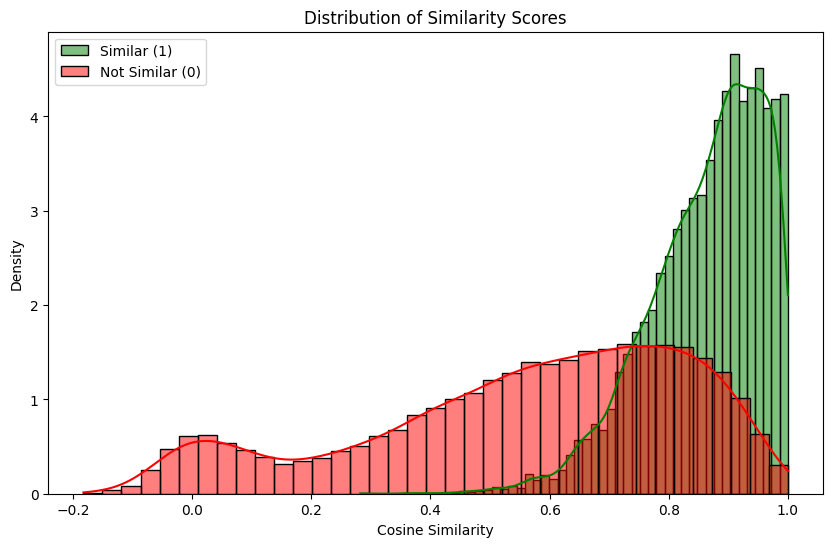

In [17]:
# let's plot density 0/1 is_duplicate and similarity score for each question
plt.figure(figsize=(10, 6))
sns.histplot(df_sample[df_sample['is_duplicate'] == 1]['similarity_score'],
             color='green', label='Similar (1)', kde=True, stat='density')
sns.histplot(df_sample[df_sample['is_duplicate'] == 0]['similarity_score'],
             color='red', label='Not Similar (0)', kde=True, stat='density')
plt.legend()
plt.title('Distribution of Similarity Scores')
plt.xlabel('Cosine Similarity')
plt.show()

In [20]:
import numpy as np

# K Means from scratch

# 1. pick k initial centers (let's pick k random datapoints)
# 2. every datapoint is clustered with the one center with least distance -> Clustering function
# 3. Recenter each cluster's center by taking the average coordinate of the cluster
# 4. Repeat step 2 and 3 until centers of clusters stop moving (or max_iterations)

class k_means():
  def __init__(self, k=5, max_iterations=100):
    self.k = k
    self.max_iterations = max_iterations
    self.centers = None # List of cluster centers
    self.labels = None

  def calc_distance(self, p1, p2):
    return np.sum((p1-p2)**2)

  def clustering(self, X):
    # X.shape = n_samples, n_features
    n_samples = X.shape[0]
    labels = np.zeros(n_samples, dtype = int)
    for i in range(n_samples):
      distances = [self.calc_distance(X[i], center) for center in self.centers]
      closest_center = np.argmin(distances)
      labels[i] = closest_center
    return labels

  def update_cluster_centers(self, X):
    n_features = X.shape[1]
    new_centers = np.zeros((self.k, n_features))
    for i in range(self.k):
      points_in_cluster = X[self.labels==i]

      if len(points_in_cluster) > 0:
        new_centers[i] = np.mean(points_in_cluster, axis=0)
      else:
        new_centers[i] = X[np.random.choice(X.shape[0])]
    return new_centers

  def fit(self, X):
    n_samples, n_features = X.shape

    random_indices = np.random.choice(n_samples, self.k, replace=False)
    self.centers = X[random_indices]

    for i in range(self.max_iterations):

      self.labels = self.clustering(X)
      current_centers = self.centers.copy()
      self.centers= self.update_cluster_centers(X)

      centers_shift = np.sum((self.centers - current_centers)**2)
      if centers_shift < 1e-4:
        print(f"Converged and cluster centers stopped moving at {i+1} iterations")
        break
      elif i == self.max_iterations - 1:
        print(f"K-means did not converge after {self.max_iterations} iterations")

    print("K-means clustering complete")

In [21]:
X = unique_questions_embeddings
k_val = 8
print(f"K-Means | k={k_val}...")

kMeans = k_means(k=k_val, max_iterations=100)
kMeans.fit(X)
cluster_labels = kMeans.labels

print(f"data shape: {X.shape}")
print(f"labels shape: {cluster_labels.shape}")
print(f"first 10 labels: {cluster_labels[:10]}")

K-Means | k=8...
Converged and cluster centers stopped moving at 31 iterations
K-means clustering complete
data shape: (37770, 384)
labels shape: (37770,)
first 10 labels: [3 3 0 2 2 2 5 2 4 5]


In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"original mean: {X[:, 0].mean():.4f}")
print(f"scaled mean: {X_scaled[:, 0].mean():.4f}")

original mean: -0.0026
scaled mean: -0.0000


In [23]:
print("Performing PCA on the question embeddings")
labels = cluster_labels
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

Performing PCA on the question embeddings


In [24]:
print("Explained variance:", pca.explained_variance_ratio_)
print("Cumulative:", np.cumsum(pca.explained_variance_ratio_))

Explained variance: [0.02632434 0.02314966]
Cumulative: [0.02632434 0.04947401]


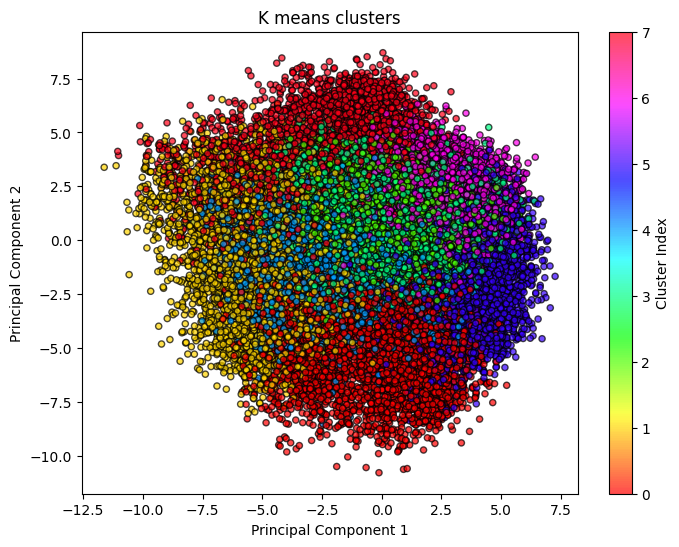

In [25]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='hsv', edgecolor='k', alpha=0.7, s=20)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K means clusters")
plt.colorbar(label="Cluster Index")
plt.show()

Running kmeans from k=2 to k=15 to calculate WCSS
Converged and cluster centers stopped moving at 17 iterations
K-means clustering complete
Converged and cluster centers stopped moving at 40 iterations
K-means clustering complete
Converged and cluster centers stopped moving at 28 iterations
K-means clustering complete
Converged and cluster centers stopped moving at 13 iterations
K-means clustering complete
Converged and cluster centers stopped moving at 18 iterations
K-means clustering complete
Converged and cluster centers stopped moving at 29 iterations
K-means clustering complete
Converged and cluster centers stopped moving at 15 iterations
K-means clustering complete
Converged and cluster centers stopped moving at 36 iterations
K-means clustering complete
Converged and cluster centers stopped moving at 24 iterations
K-means clustering complete
Converged and cluster centers stopped moving at 13 iterations
K-means clustering complete
Converged and cluster centers stopped moving at 19

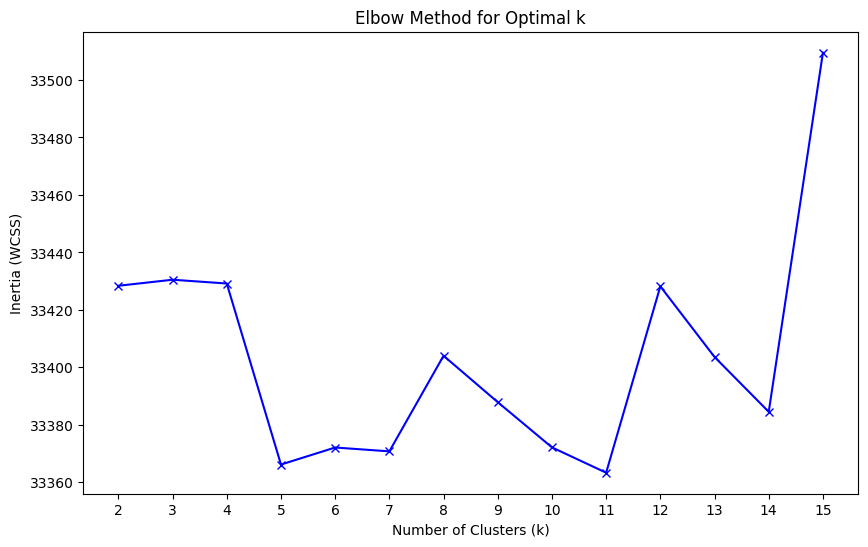

In [28]:
# Experimenting with different n_cluster values (Elbow method)
def calculate_inertia(kmeans_model, X):
    total_inertia = 0
    n_samples = X.shape[0]

    for i in range(n_samples):
        label = kMeans.labels[i]
        center = kMeans.centers[label]
        total_inertia += np.sum((X[i] - center)**2)
    return total_inertia

k_range = range(2, 16)
inertia_values = []

print("Running kmeans from k=2 to k=15 to calculate WCSS")

for k in k_range:
    kMeans = k_means(k=k_val, max_iterations=100)
    kMeans.fit(X)

    if kMeans.labels is not None:
        inertia = calculate_inertia(kMeans, X)
        inertia_values.append(inertia)
    else:
        print(f"k={k} - error.")
        inertia_values.append(np.nan)


plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_values, 'bx-')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(k_range)
plt.show()



In [29]:
# current k = 15
cluster_df = pd.DataFrame({
    'Question': unique_questions_list,
    'Cluster_No.': cluster_labels
})


print("Cluster sizes :")
cluster_counts = cluster_df['Cluster_No.'].value_counts()
largest_cluster = cluster_counts.index[0]
print(cluster_counts)
print("\n")

SAMPLE_SIZE = 15
print(f"Sample questions from the largest cluster")

questions_in_cluster = cluster_df[cluster_df['Cluster_No.'] == largest_cluster]['Question'].sample(SAMPLE_SIZE, random_state=42)
questions_in_cluster

Cluster sizes :
Cluster_No.
3    6699
2    6047
6    4887
0    4316
4    4246
5    4234
1    4161
7    3180
Name: count, dtype: int64


Sample questions from the largest cluster


,Question
13932,How do free online games earn money?
12673,Find password for email?
31245,How do you get a product into the As Seen On T...
17408,How can I solve EDB-ID-15666 problem?
1591,Is now a good time to invest in the California...
4019,Why can't I scroll down on my laptop? How do I...
35865,Will DSPs (demand side platform) and RTB (real...
23148,Do people on Quora disproportionately either a...
17927,Is a brain transplant theoretically possible?
2789,How can I see the delete message of viber?


In [30]:
smallest_cluster = cluster_counts.index[-1]
smallest_cluster_size = cluster_counts.iloc[-1]

SAMPLE_SIZE = min(15, smallest_cluster_size)
print(f"Sample questions from the smallest cluster")

questions_in_cluster = cluster_df[cluster_df['Cluster_No.'] == smallest_cluster]['Question'].sample(SAMPLE_SIZE, random_state=42)
questions_in_cluster

Sample questions from the smallest cluster


,Question
12703,Why are non-malayalis on Quora so insistent on...
18110,Why did Tata Sons removed/sacked Cyrus Mistry ...
9796,Can Pakistan be declared a terrorist nation? H...
5213,What is bhahubali collections?
13579,Which building has the best architecture in Ba...
7740,How long does it take to get Voter Id card in ...
7714,Where are the eight immortals of Indian mythol...
34276,Why are foreigners reviewing Indian movie trai...
1899,Which are the best short movies on Youtube mad...
21730,How can I learn Tamil?


Smallest cluster seems to have some semantic similarity (India-related questions in this sample xD)